# Customer Churn Prediction — Full Notebook

## Objective
Predict whether a customer will churn using ML models and evaluate performance with standard metrics.

## Models we will try
- Random Forest
- XGBoost
- LightGBM
- Logistic Regression
- CatBoost
- Soft Voting Classifier
  

# Libraries


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# 1) Load DataSet

In [92]:
df = pd.read_csv("Churn.csv")



In [93]:
print("Shape:", df.shape)


Shape: (7043, 21)


# 2) Basic Inspection
Check sample rows, columns, data types, and general info.


In [95]:
display(df.head(5))



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [96]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [97]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [98]:
print("\nCOLUMNS:")
print(df.columns.tolist())




COLUMNS:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [99]:
print("\nDATA TYPES:")
display(df.dtypes)



DATA TYPES:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [100]:
print("\nINFO:")
df.info()


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   o

<a id = "" ></a>
# <span style="font-family:serif; font-size:28px;"> 3) DataPreprocessing</span>
<a id = "Data Preprocessing" ></a>

## 3) Data Preprocessing
We will check:
- Missing values
- Duplicate rows
- Basic unique values for categorical columns


In [103]:
print(df.isna().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [104]:
print("\n=== Duplicate Rows ===")
print("Duplicates:", df.duplicated().sum())


=== Duplicate Rows ===
Duplicates: 0


In [105]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", len(cat_cols))
car_cols = df.columns
for c in cat_cols:
    print(f"{c} -> {df[c].nunique()} unique | sample: {df[c].unique()[:6]}")


Categorical columns: 18
customerID -> 7043 unique | sample: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC']
gender -> 2 unique | sample: ['Female' 'Male']
Partner -> 2 unique | sample: ['Yes' 'No']
Dependents -> 2 unique | sample: ['No' 'Yes']
PhoneService -> 2 unique | sample: ['No' 'Yes']
MultipleLines -> 3 unique | sample: ['No phone service' 'No' 'Yes']
InternetService -> 3 unique | sample: ['DSL' 'Fiber optic' 'No']
OnlineSecurity -> 3 unique | sample: ['No' 'Yes' 'No internet service']
OnlineBackup -> 3 unique | sample: ['Yes' 'No' 'No internet service']
DeviceProtection -> 3 unique | sample: ['No' 'Yes' 'No internet service']
TechSupport -> 3 unique | sample: ['No' 'Yes' 'No internet service']
StreamingTV -> 3 unique | sample: ['No' 'Yes' 'No internet service']
StreamingMovies -> 3 unique | sample: ['No' 'Yes' 'No internet service']
Contract -> 3 unique | sample: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -> 2 unique | sample: ['Ye

##  Cleaning & Fixing Data Types
In dataset:
- Replace blank spaces `" "` in `TotalCharges` with `NaN`
- `TotalCharges` often loads as text (object), so we convert it to `float`.
-  Fill missing `TotalCharges` values using mean
- We will drop `customerID` because it's just an identifier.


In [107]:
df["TotalCharges"] = df["TotalCharges"].replace(" " , np.nan)

df["TotalCharges"] = df["TotalCharges"].astype(float)
df.drop_duplicates(inplace=True)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())
df = df.drop(columns=["customerID"])

In [108]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 48, df["tenure"].max()],
    labels=["New", "Mid-term", "Loyal"]
).astype("object")


In [109]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Mid-term
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Mid-term
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New


## Outliers

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# (Make sure TotalCharges numeric)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# ---- 1) Detect outliers using IQR ----
outlier_report = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report.append([col, lower, upper, len(outliers)])

outlier_report = pd.DataFrame(outlier_report, columns=["Feature","LowerBound","UpperBound","OutlierCount"])
print(outlier_report)

# ---- 2) OPTIONAL: Cap (Winsorize) outliers instead of removing ----
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)

print("IQR capping done.")


          Feature  LowerBound  UpperBound  OutlierCount
0          tenure    -60.0000    124.0000             0
1  MonthlyCharges    -46.0250    171.3750             0
2    TotalCharges  -4674.3375   8863.1625             0
✅ IQR capping done.


# EDA 

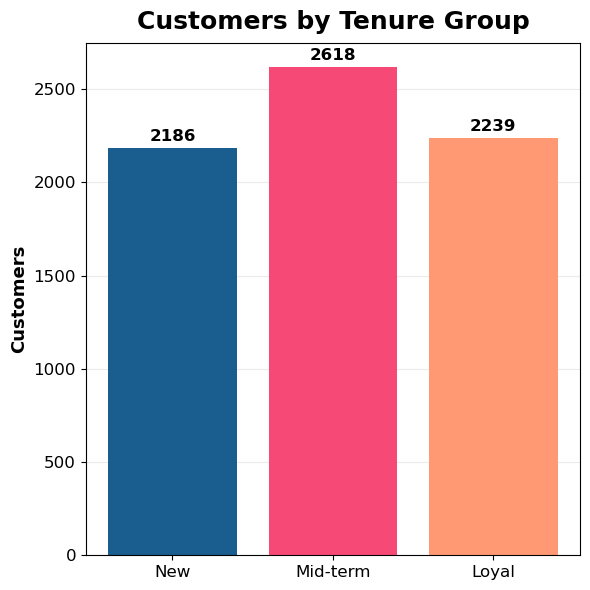

In [113]:

COLS = ["#1a5e8f", "#f64975", "#ff9973"]   

tg = df["tenure_group"].value_counts().reindex(["New","Mid-term","Loyal"])

plt.figure(figsize=(6,6))
ax = plt.gca()

bars = ax.bar(tg.index.astype(str), tg.values, color=COLS)

ax.set_title("Customers by Tenure Group", fontsize=18, fontweight="bold", pad=10)
ax.set_ylabel("Customers", fontsize=13, fontweight="bold")

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(labelsize=12)

ax.bar_label(bars, padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("tenuregroup.png", dpi=300, bbox_inches="tight")
plt.show()


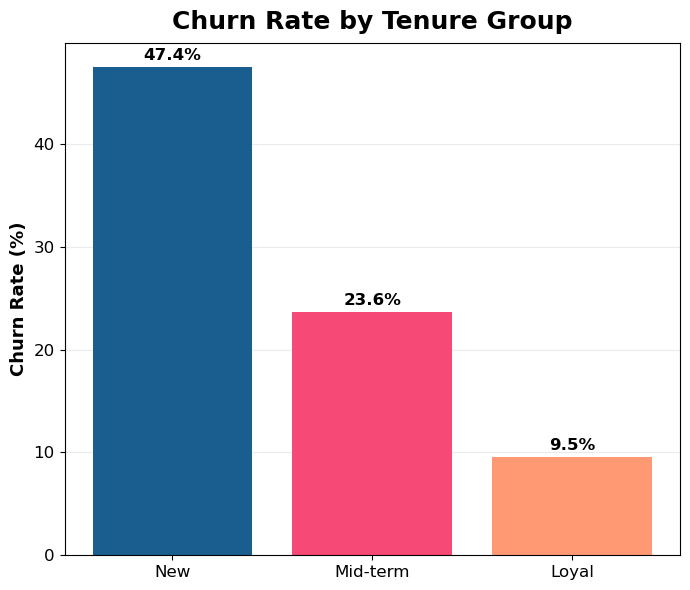

In [114]:
import matplotlib.pyplot as plt
churn_rate = (
    df.groupby("tenure_group")["Churn"]
      .apply(lambda s: (s.eq("Yes").mean()*100) if s.dtype == "object" else (s.mean()*100))
      .sort_index()
)


churn_rate = churn_rate.reindex(["New", "Mid-term", "Loyal"])  

COLS = ["#1a5e8f", "#f64975", "#ff9973"]  

plt.figure(figsize=(7,6))
ax = plt.gca()

bars = ax.bar(churn_rate.index.astype(str), churn_rate.values, color=COLS)

ax.set_title("Churn Rate by Tenure Group", fontsize=18, fontweight="bold", pad=10)
ax.set_ylabel("Churn Rate (%)", fontsize=13, fontweight="bold")

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(labelsize=12)

ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("tenuregroup_churnrate.png", dpi=300, bbox_inches="tight")
plt.show()



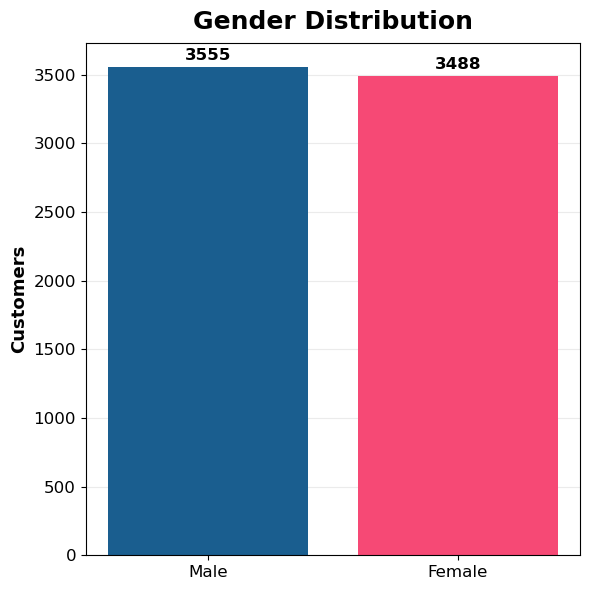

In [115]:
COLS = ["#1a5e8f", "#f64975"]  
g = df["gender"].value_counts()

plt.figure(figsize=(6,6))
ax = plt.gca()

bars = ax.bar(g.index.astype(str), g.values, color=COLS)

ax.set_title("Gender Distribution", fontsize=18, fontweight="bold", pad=10)
ax.set_ylabel("Customers", fontsize=13, fontweight="bold")

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(labelsize=12)

ax.bar_label(bars, padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("genderdistribution.png", dpi=300, bbox_inches="tight")
plt.show()


# Encoding

### Binary Column Encoding

In [118]:
binary_cols = ["Churn"]

for c in binary_cols:
    df[c] = df[c].map({"No": 0, "Yes": 1}).astype(int)
    


## Correlational

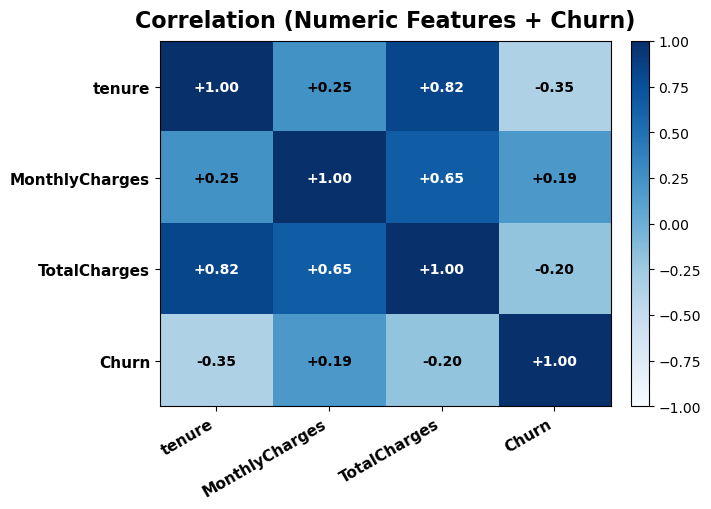

In [120]:

corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(7.2, 5.2))
ax = plt.gca()
im = ax.imshow(corr.values, aspect="auto", cmap="Blues", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=30, ha="right", fontsize=11, fontweight="bold")
ax.set_yticklabels(corr_cols, fontsize=11, fontweight="bold")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:+.2f}", ha="center", va="center",
                fontsize=10, fontweight="bold",
                color="white" if abs(val) > 0.55 else "black")

plt.title("Correlation (Numeric Features + Churn)", fontsize=16, fontweight="bold", pad=10)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### One Hot Encoding on Remaining Column 

In [122]:
df = pd.get_dummies(df, columns=df.columns.drop("Churn"), drop_first=True, dtype=int)

## Data Frame After Preprocessing

In [124]:
df.head()

,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,tenure_1,tenure_2,tenure_3,tenure_4,tenure_5,...,TotalCharges_8529.5,TotalCharges_8543.25,TotalCharges_8547.15,TotalCharges_8564.75,TotalCharges_8594.4,TotalCharges_8670.1,TotalCharges_8672.45,TotalCharges_8684.8,tenure_group_Mid-term,tenure_group_New
0,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## Number of Churn and Not Churn Cases
### The numbers shows that there is class imbalance 

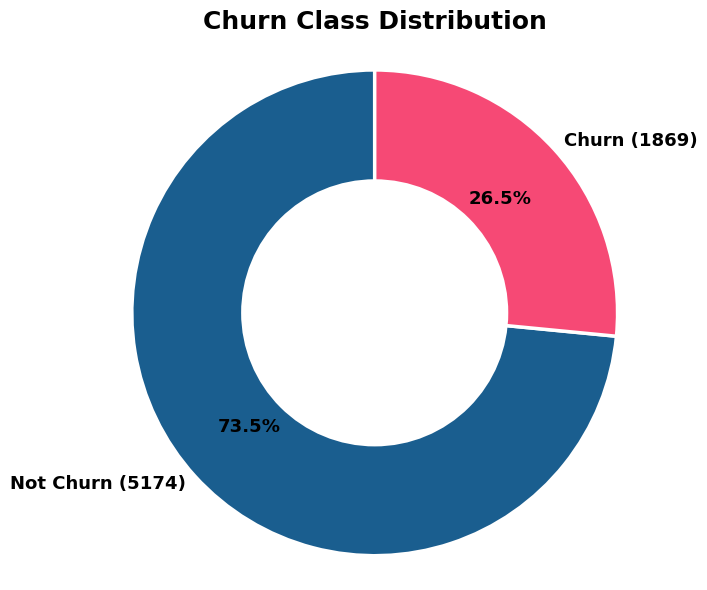

In [ ]:
import matplotlib.pyplot as plt

counts = df["Churn"].value_counts().sort_index()
label_map = {0: "Not Churn", 1: "Churn"}

labels = [f"{label_map[i]} ({counts[i]})" for i in counts.index]
sizes  = counts.values

COLS = ["#1a5e8f", "#f64975"]

plt.figure(figsize=(7,6))
ax = plt.gca()

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=COLS,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 13, "fontweight": "bold"},
    pctdistance=0.70,    
    labeldistance=1.05  
)

for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight("bold")

# donut hole
centre = plt.Circle((0,0), 0.55, fc="white")
ax.add_artist(centre)

ax.set_title("Churn Class Distribution", fontsize=18, fontweight="bold", pad=12)
ax.axis("equal")

plt.tight_layout()
plt.savefig("churn_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## Handling Class Imbalance And Train_Test_Split

In [128]:
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

sampler = SMOTETomek(random_state=42)
X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)


### Random Forest 

In [130]:

rf = RandomForestClassifier( n_estimators=500,random_state=42)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf =  precision_score(y_test, y_pred_rf)
re_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", acc_rf)
print("Precision:", pre_rf)
print("Recall   :", re_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.7175301632363378
Precision: 0.48085758039816234
Recall   : 0.8418230563002681
F1 Score : 0.6120857699805068


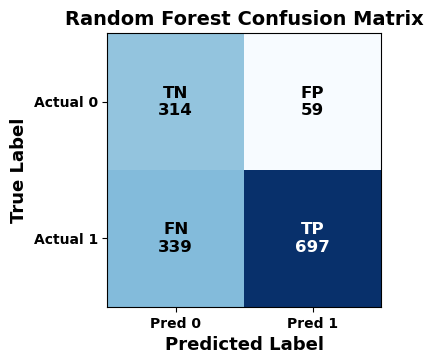

In [131]:
cm = confusion_matrix(y_test, y_pred_rf, labels=[1, 0])  


plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues", aspect="equal")

plt.xticks([0,1], ["Pred 0","Pred 1"], fontsize=10, fontweight="bold")
plt.yticks([0,1], ["Actual 0","Actual 1"], fontsize=10, fontweight="bold")
plt.title("Random Forest Confusion Matrix", fontsize=14, fontweight="bold")

tags = [["TN","FP"],["FN","TP"]]   
th = cm.max() / 2

for i in range(2):
    for j in range(2):
        plt.text( j, i, f"{tags[i][j]}\n{cm[i,j]}", ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if cm[i,j] > th else "black"
        )

plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_rf.png", dpi=300, bbox_inches="tight")
plt.show()


### XGBOOST

In [133]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    subsample=0.9,
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

y_pred = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred)
pre_xgb = precision_score(y_test, y_pred)
re_xgb = recall_score(y_test, y_pred)
f1_xgb = f1_score(y_test, y_pred)

print("Accuracy :", acc_xgb)
print("Precision:", pre_xgb)
print("Recall   :", re_xgb)
print("F1 Score :", f1_xgb)


Accuracy : 0.751596877217885
Precision: 0.5204262877442274
Recall   : 0.7855227882037533
F1 Score : 0.6260683760683761


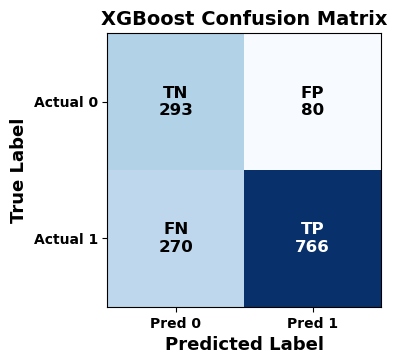

In [134]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues", aspect="equal")
plt.xticks([0,1], ["Pred 0","Pred 1"], fontsize=10, fontweight="bold")
plt.yticks([0,1], ["Actual 0","Actual 1"], fontsize=10, fontweight="bold")
plt.title("XGBoost Confusion Matrix", fontsize=14, fontweight="bold")

tags = [["TN","FP"],["FN","TP"]]   
th = cm.max() / 2

for i in range(2):
    for j in range(2):
        plt.text( j, i, f"{tags[i][j]}\n{cm[i,j]}", ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if cm[i,j] > th else "black"
        )

plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

### LGBM

In [136]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01,
    subsample=0.9,
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train_res, y_train_res)

y_pred = lgbm.predict(X_test)

acc_lgbm = accuracy_score(y_test, y_pred)
pre_lgbm = precision_score(y_test, y_pred)
re_lgbm = recall_score(y_test, y_pred)
f1_lgbm = f1_score(y_test, y_pred)

print("Accuracy :", acc_lgbm)
print("Precision:", pre_lgbm)
print("Recall   :", re_lgbm)
print("F1 Score :", f1_lgbm)


Accuracy : 0.7750177430801988
Precision: 0.5538461538461539
Recall   : 0.7721179624664879
F1 Score : 0.64501679731243


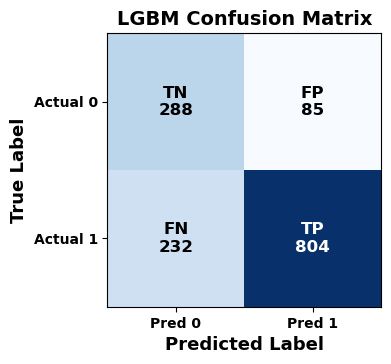

In [137]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # [[TP,FN],[FP,TN]]

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues", aspect="equal")
plt.xticks([0,1], ["Pred 0","Pred 1"], fontsize=10, fontweight="bold")
plt.yticks([0,1], ["Actual 0","Actual 1"], fontsize=10, fontweight="bold")
plt.title("LGBM Confusion Matrix", fontsize=14, fontweight="bold")

tags = [["TN","FP"],["FN","TP"]]   
th = cm.max() / 2

for i in range(2):
    for j in range(2):
        plt.text( j, i, f"{tags[i][j]}\n{cm[i,j]}", ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if cm[i,j] > th else "black"
        )

plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_lgbm.png", dpi=300, bbox_inches="tight")
plt.show()



## Logistic Regression

In [139]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=500, random_state=42)

lr.fit(X_train_res, y_train_res)

y_pred = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred)
pre_lr = precision_score(y_test, y_pred)
re_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)

print("Accuracy :", acc_lr)
print("Precision:", pre_lr)
print("Recall   :", re_lr)
print("F1 Score :", f1_lr)


Accuracy : 0.7849538679914834
Precision: 0.5723140495867769
Recall   : 0.7426273458445041
F1 Score : 0.646441073512252


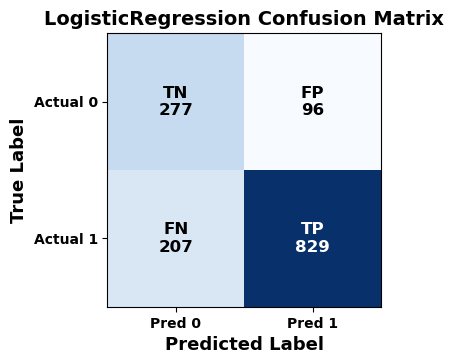

In [140]:

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # [[TP,FN],[FP,TN]]

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues", aspect="equal")
plt.xticks([0,1], ["Pred 0","Pred 1"], fontsize=10, fontweight="bold")
plt.yticks([0,1], ["Actual 0","Actual 1"], fontsize=10, fontweight="bold")
plt.title("LogisticRegression Confusion Matrix", fontsize=14, fontweight="bold")

tags = [["TN","FP"],["FN","TP"]]   
th = cm.max() / 2

for i in range(2):
    for j in range(2):
        plt.text( j, i, f"{tags[i][j]}\n{cm[i,j]}", ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if cm[i,j] > th else "black"
        )

plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_lr.png", dpi=300, bbox_inches="tight")
plt.show()


In [141]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cat = CatBoostClassifier(
    iterations=800,
    learning_rate=0.01,
    depth=6,
    loss_function="Logloss",
    verbose=0,
    random_seed=42
)

cat.fit(X_train_res, y_train_res)

y_pred = cat.predict(X_test)

acc_cat = accuracy_score(y_test, y_pred)
pre_cat = precision_score(y_test, y_pred, zero_division=0)
re_cat  = recall_score(y_test, y_pred, zero_division=0)
f1_cat  = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", acc_cat)
print("Precision:", pre_cat)
print("Recall   :", re_cat)
print("F1 Score :", f1_cat)


Accuracy : 0.7608232789212207
Precision: 0.5316901408450704
Recall   : 0.8096514745308311
F1 Score : 0.6418703506907545


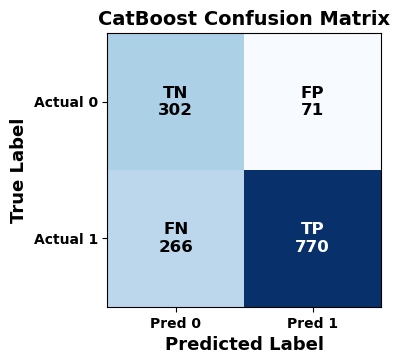

In [142]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # [[TP,FN],[FP,TN]]

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues", aspect="equal")
plt.xticks([0,1], ["Pred 0","Pred 1"], fontsize=10, fontweight="bold")
plt.yticks([0,1], ["Actual 0","Actual 1"], fontsize=10, fontweight="bold")
plt.title("CatBoost Confusion Matrix", fontsize=14, fontweight="bold")

tags = [["TN","FP"],["FN","TP"]]   
th = cm.max() / 2

for i in range(2):
    for j in range(2):
        plt.text( j, i, f"{tags[i][j]}\n{cm[i,j]}", ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if cm[i,j] > th else "black"
        )

plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_cat.png", dpi=300, bbox_inches="tight")
plt.show()


## Finding best treshold 

In [144]:
p_rf = rf.predict_proba(X_test)[:,1]
p_xgb  = xgb.predict_proba(X_test)[:, 1]
p_lgbm = lgbm.predict_proba(X_test)[:, 1]
p_lr   = lr.predict_proba(X_test)[:, 1]
p_cat  = cat.predict_proba(X_test)[:, 1]


avg_prob = ( p_lr  + p_lgbm+p_rf+ p_cat + p_xgb ) / 5


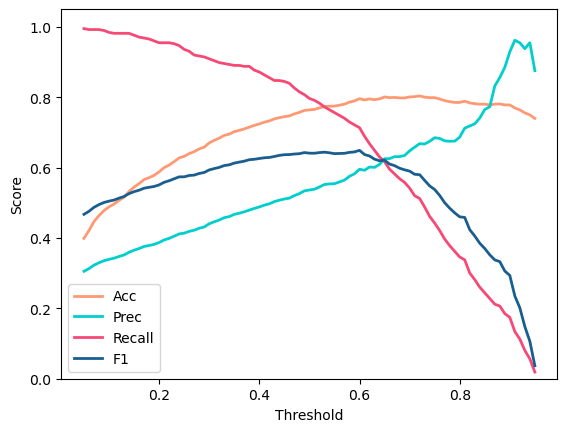

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thrs = np.arange(0.05, 0.96, 0.01)

acc, pre, rec, f1 = [], [], [], []
for t in thrs:
    yhat = (avg_prob >= t).astype(int)
    acc.append(accuracy_score(y_test, yhat))
    pre.append(precision_score(y_test, yhat, zero_division=0))
    rec.append(recall_score(y_test, yhat, zero_division=0))
    f1.append(f1_score(y_test, yhat, zero_division=0))

plt.plot(thrs, acc, label="Acc",    color="#ff9973",   linewidth=2)
plt.plot(thrs, pre, label="Prec",   color="#00cfcc", linewidth=2)
plt.plot(thrs, rec, label="Recall", color="#f64975",  linewidth=2)
plt.plot(thrs, f1,  label="F1",     color="#1a5e8f",    linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(False)
plt.legend()
plt.savefig("treshold.png", dpi=300, bbox_inches="tight")
plt.show()


In [146]:
t_best=0.60

## Voting Classifier 

In [148]:


y_pred_vote = (avg_prob >= t_best).astype(int)

acc_vc = accuracy_score(y_test, y_pred_vote)
pre_vc = precision_score(y_test, y_pred_vote)
re_vc = recall_score(y_test, y_pred_vote)
f1_vc = f1_score(y_test, y_pred_vote)

print("Accuracy :", acc_vc)
print("Precision:", pre_vc)
print("Recall   :", re_vc)
print("F1 Score :", f1_vc)


Accuracy : 0.7955997161107168
Precision: 0.5950782997762863
Recall   : 0.7131367292225201
F1 Score : 0.6487804878048781


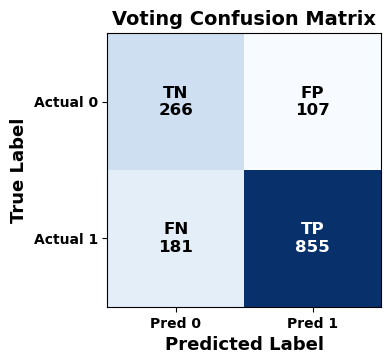

In [149]:
cm = confusion_matrix(y_test, y_pred_vote, labels=[1, 0])  # [[TP,FN],[FP,TN]]

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues", aspect="equal")
plt.xticks([0,1], ["Pred 0","Pred 1"], fontsize=10, fontweight="bold")
plt.yticks([0,1], ["Actual 0","Actual 1"], fontsize=10, fontweight="bold")
plt.title("Voting Confusion Matrix", fontsize=14, fontweight="bold")

tags = [["TN","FP"],["FN","TP"]]   
th = cm.max() / 2

for i in range(2):
    for j in range(2):
        plt.text( j, i, f"{tags[i][j]}\n{cm[i,j]}", ha="center", va="center", fontsize=12, fontweight="bold",
            color="white" if cm[i,j] > th else "black"
        )

plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_vote.png", dpi=300, bbox_inches="tight")
plt.show()


## WHERE ALL MODELS FAILED

In [151]:
pred_rf  = rf.predict(X_test)
pred_xgb  = xgb.predict(X_test)
pred_lgbm = lgbm.predict(X_test)
pred_lr = lr.predict(X_test)
pred_cat = lr.predict(X_test)
y_true = y_test.values

same_wrong_0 =  (pred_rf==0) & (pred_xgb==0) & (pred_lgbm==0) & (pred_lr==0) & (pred_cat==0) & (y_true==1)  # missed churn
same_wrong_1 =  (pred_rf==1) & (pred_xgb==1) & (pred_lgbm==1) & (pred_lr==1) & (pred_cat==1) & (y_true==0)  # false alarm



print("Same wrong (all 0 but actual 1):", same_wrong_0.sum())
print("Same wrong (all 1 but actual 0):", same_wrong_1.sum())



Same wrong (all 0 but actual 1): 47
Same wrong (all 1 but actual 0): 171


## Bootstrap

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def bootstrap_stratified(prob, y, thr=0.60, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    prob = np.asarray(prob)
    y = np.asarray(y)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    scores = []
    for _ in tqdm(range(n_boot), desc=f"Bootstrapping (thr={thr:.2f})"):
        b0 = rng.choice(idx0, size=len(idx0), replace=True)
        b1 = rng.choice(idx1, size=len(idx1), replace=True)
        idx = np.concatenate([b0, b1])

        yb = y[idx]
        pb = prob[idx]
        pred = (pb >= thr).astype(int)

        scores.append([
            accuracy_score(yb, pred),
            precision_score(yb, pred, zero_division=0),
            recall_score(yb, pred, zero_division=0),
            f1_score(yb, pred, zero_division=0)
        ])

    df = pd.DataFrame(scores, columns=["accuracy","precision","recall","f1"])
    summary = df.quantile([0.025, 0.975])
    summary.columns = ["CI_low", "CI_high"]
    summary["CI_width"] = summary["CI_high"] - summary["CI_low"]
    return summary


In [196]:
thr = 0.60

summaries = {}
summaries["RF"]   = bootstrap_stratified(p_rf,   y_test, thr=thr)
summaries["XGB"]  = bootstrap_stratified(p_xgb,  y_test, thr=thr)
summaries["LGBM"] = bootstrap_stratified(p_lgbm, y_test, thr=thr)
summaries["LR"]   = bootstrap_stratified(p_lr,   y_test, thr=thr)
summaries["CB"]   = bootstrap_stratified(p_cat,   y_test, thr=thr)

summaries["Vote"] = bootstrap_stratified(avg_prob, y_test, thr=thr)

# Combine into one table
final = pd.concat(summaries, names=["Model","Metric"]).reset_index()
final = final.rename(columns={"level_0":"Model","level_1":"Metric"})
print(final)


Bootstrapping (thr=0.60): 100%|████████████| 1000/1000 [00:02<00:00, 343.01it/s]

   Model     Metric    CI_low   CI_high  CI_width
0     RF   accuracy  0.731725  0.779276  0.047551
1     RF  precision  0.495575  0.557508  0.061933
2     RF     recall  0.731903  0.817694  0.085791
3     RF         f1  0.595923  0.657312  0.061390
4    XGB   accuracy  0.767211  0.809102  0.041891
5    XGB  precision  0.548032  0.619056  0.071024
6    XGB     recall  0.659517  0.753351  0.093834
7    XGB         f1  0.606130  0.672195  0.066065
8   LGBM   accuracy  0.777839  0.817601  0.039762
9   LGBM  precision  0.569213  0.641152  0.071938
10  LGBM     recall  0.632708  0.726542  0.093834
11  LGBM         f1  0.604043  0.675846  0.071803
12    LR   accuracy  0.774308  0.813343  0.039035
13    LR  precision  0.568122  0.645353  0.077231
14    LR     recall  0.581769  0.678351  0.096582
15    LR         f1  0.581130  0.654697  0.073566
16    CB   accuracy  0.767921  0.810504  0.042583
17    CB  precision  0.549470  0.621250  0.071780
18    CB     recall  0.656836  0.747989  0.091153
